## Setup

In [63]:
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.max_seq_items", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 120)


## Load datasets

In [64]:
DATA_DIR = "../data"  # adjust to your actual folder structure

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/validation.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

splits = {"train": train_df, "validation": val_df, "test": test_df}


## 1. Data Shape

In [65]:
for df_name, df in splits.items():
    print(f"{df_name}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"  missing text:  {df['text'].isna().sum()}")
    print(f"  missing label: {df['label'].isna().sum()}")


train: 2270 rows, 116 columns
  missing text:  0
  missing label: 0
validation: 568 rows, 116 columns
  missing text:  0
  missing label: 0
test: 715 rows, 116 columns
  missing text:  0
  missing label: 0


## 2. Label Balance

**Question:** Is the target balance?

In [66]:
for name, df in splits.items():
    print(f"\n{name}:")
    print(df["label"].value_counts(normalize=True).round(3))



train:
label
1    0.519
0    0.481
Name: proportion, dtype: float64

validation:
label
1    0.546
0    0.454
Name: proportion, dtype: float64

test:
label
1    0.516
0    0.484
Name: proportion, dtype: float64


**Takeaway**: Around 52/48 across all three splits, no class weighting needed

## 3. Cross-split leakage check

**Question:** does the same post ever appear in more than one split?

In [67]:
train_ids = set(train_df["post_id"])
val_ids   = set(val_df["post_id"])
test_ids  = set(test_df["post_id"])

print("train & validation overlap:", len(train_ids & val_ids))
print("train & test overlap:      ", len(train_ids & test_ids))
print("validation & test overlap: ", len(val_ids & test_ids))


train & validation overlap: 136
train & test overlap:       0
validation & test overlap:  0


In [68]:
# check overlap - 136 rows in both train and validation
print(len(val_df))
print(136 / len(val_df))

568
0.23943661971830985


In [69]:
overlap_ids = train_ids & val_ids

rows_to_drop = train_df[train_df["post_id"].isin(overlap_ids)]
print(len(rows_to_drop), "rows out of", len(train_df))
print(len(rows_to_drop) / len(train_df))

174 rows out of 2270
0.07665198237885462


In [70]:
train_df[train_df["post_id"].isin(overlap_ids)]["post_id"].value_counts()

post_id
7m9h5q    4
8xqnpo    3
8vlb0k    3
7cbb5z    3
5n56lm    3
         ..
62doqq    1
7nk62d    1
87fkbw    1
7tdu4v    1
78tayl    1
Name: count, Length: 136, dtype: int64

In [71]:
train_df_clean = train_df[~train_df["post_id"].isin(overlap_ids)].reset_index(drop=True)

assert len(set(train_df_clean["post_id"]) & val_ids) == 0
print("Rows before:", len(train_df), "-> after:", len(train_df_clean))

print(train_df["label"].value_counts(normalize=True).round(3))
print(train_df_clean["label"].value_counts(normalize=True).round(3))

train_df_clean.to_csv("../data/train_clean.csv", index=False)

Rows before: 2270 -> after: 2096
label
1    0.519
0    0.481
Name: proportion, dtype: float64
label
1    0.528
0    0.472
Name: proportion, dtype: float64


In [72]:
train_df_clean["post_id"].value_counts().value_counts()


count
1    1573
2     192
3      27
5       6
4       4
6       2
Name: count, dtype: int64

## 4. Subreddit classification distribution

**Question:** could a model learn "which subreddit is this" as a shortcut for the actual label, instead of learning from the content?

In [73]:
pd.crosstab(train_df_clean["subreddit"], train_df_clean["label"], normalize="index").round(3)


label,0,1
subreddit,,
almosthomeless,0.440,0.560
anxiety,0.331,0.669
assistance,0.619,0.381
domesticviolence,0.364,0.636
food_pantry,0.565,0.435
homeless,0.623,0.377
ptsd,0.437,0.563
relationships,0.553,0.447
stress,0.392,0.608


## 5. Text length by label

**Question:** do stress and not-stress posts differ systematically in
length? If so, a model could partly learn "length" as a proxy instead of content  (worth knowing before it shows up unexplained in SHAP later.)


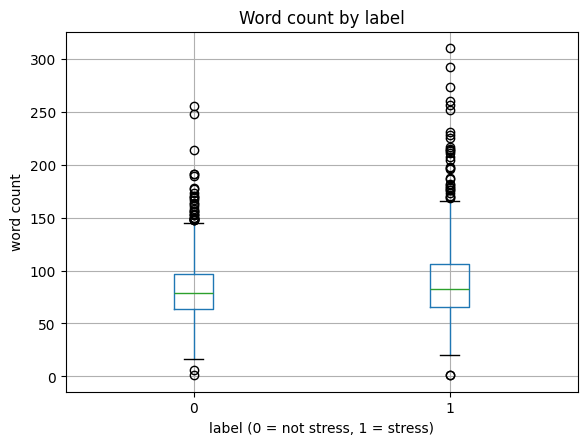

,mean,50%,std
label,,,
0,83.024242,78.5,29.452287
1,89.003617,83.0,35.452039


In [74]:
train_df_clean["word_count"] = train_df_clean["text"].str.split().str.len()

train_df_clean.boxplot(column="word_count", by="label")
plt.title("Word count by label")
plt.suptitle("")
plt.xlabel("label (0 = not stress, 1 = stress)")
plt.ylabel("word count")
plt.show()

train_df_clean.groupby("label")["word_count"].describe()[["mean", "50%", "std"]]


## Summary of findings

**Label balance:** ~52/48 (stress/not-stress) in train, consistent enough
across splits that no class weighting is needed.

**Cross-split leakage (found and fixed):** train/validation post_id
intersection initially showed 136 overlapping posts (174 rows, 7.7% of
train). Not exact duplicate text. This dataset splits original Reddit
posts into multiple overlapping segments (`post_id` + `sentence_range`),
so parts of the same post could land in both train and validation.
Fixed by removing the 174 overlapping rows from train rather than from
validation, since that meant losing 7.7% of train versus 24% of validation. 

**Subreddit distribution:** Uneven `ptsd`, `relationships`, and
`anxiety` dominate; the `stress` subreddit itself is one of the smallest
categories (55 posts). Per-subreddit stress rates range from ~34%
(`anxiety`) to ~62% (`assistance`, `homeless`, `food_pantry`).

**Decisions this EDA leads to:**
- Use the leakage-filtered training set going forward, not the raw
  Hugging Face train export
- Keep `subreddit` in the data for later error analysis, but exclude it
  as a model input
